In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import numpy as np

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS
from backend.modeling.sarima_model import SARIMAModel
from backend.modeling.prophet_model import ProphetModel
from sklearn.preprocessing import MinMaxScaler
from backend.modeling.xgboost_model import XGBoostModel

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [3]:
water_engineered_path = PATHS['engineered_data'] / 'water_engineered.parquet'
df = pd.read_parquet(water_engineered_path)
df.head()

,date,storage,capacity,crest_elevation,province,autonomous_community,id,year,month,day,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w,week_idx
0,1988-01-05,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,5,0,NaN,NaN,NaN,NaN,NaN,103.0,NaN,1
1,1988-01-12,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,12,0,103.0,NaN,NaN,NaN,NaN,103.0,0.0,2
2,1988-01-19,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,19,0,103.0,103.0,NaN,NaN,NaN,103.0,0.0,3
3,1988-01-26,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,26,0,103.0,103.0,103.0,NaN,NaN,103.0,0.0,4
4,1988-02-02,103.0,103.0,NaN,cordoba,andalucia,1,1988,2,2,0,103.0,103.0,103.0,103.0,NaN,103.0,0.0,5


c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:51:47 - cmdstanpy - INFO - Chain [1] star

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:51:47 - cmdstanpy - INFO - Chain [1] star

SARIMA and Prophet base models trained successfully
Aligned lag data shape: (311, 25)
Final data shape with base model features: (0, 27)
Insufficient training data for stacking model


c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:51:47 - cmdstanpy - INFO - Chain [1] star

SARIMA and Prophet base models trained successfully
Aligned lag data shape: (311, 25)
Final data shape with base model features: (0, 27)
Insufficient training data for stacking model


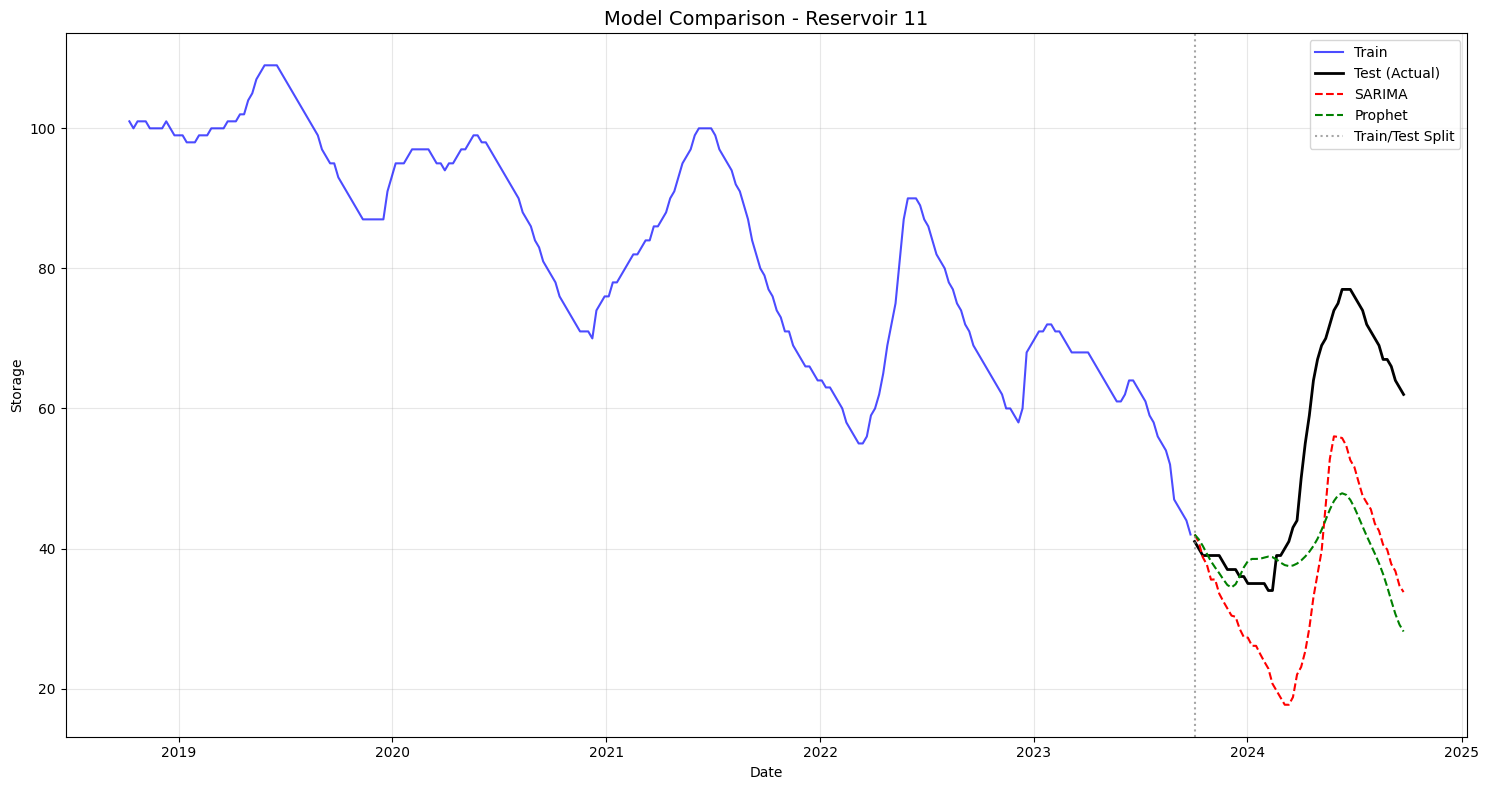


=== Stacking Model Features ===
XGBoost uses the following as input features:
- Historical lag features (1-8 weeks, 46-58 weeks)
- Temporal features (year, month, week)
- SARIMA predictions (as reference feature)
- Prophet predictions (as reference feature)

This creates a true stacking ensemble where base model predictions inform the meta-learner.


In [8]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train_series = series.iloc[-(52*6):-52] # ENTRENAR CROSS VALIDATION PARA IR PREDICIENDO Y METERLO EN EL TRAINING DATA
test_series = series.iloc[-52:] # PERO HACERLO EN LA CELDA DE ABAJO

# Step 1: Train SARIMA and Prophet on the training data
sarima_model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
sarima_model.fit(train_series)

prophet_model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.05)
prophet_model.fit(train_series)

# Get test predictions from base models
sarima_test_pred = sarima_model.predict(steps=52)
prophet_test_pred = prophet_model.predict(52)

print("SARIMA and Prophet base models trained successfully")

# Step 2: Prepare XGBoost data with base model predictions as features
df_res.set_index('date', inplace=True)
df_res = df_res.iloc[-(52*8):] # ESTO COGE LOS ÚLTIMOS 8 AÑOS

# Keep only storage for lag feature creation
storage_series = df_res['storage'] # EL ÍNDICE DEL XGBOOST SON LOS ÚLTIMOS 8 AÑOS ASÍ, HAY QUE PONER A 5

# Create lag features (simplified to avoid NaN issues)
lag_features = {}

for lag in range(1,9):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

for lag in range(46, 59):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

# Create DataFrame with all features at once
lag_data = pd.DataFrame({
    'year': df_res['year'].astype(float),
    'month': df_res['month'] / 12,
    'week_idx': df_res['week_idx'] / 52,
    'next_storage_value': storage_series.shift(-1),
    **lag_features  # Unpack all lag features
}, index=storage_series.index)

# Remove rows with NaN values and take last portion for consistency
lag_data_clean = lag_data.dropna()

# Get the overlapping period with our train/test split
overlap_period = pd.concat([train_series, test_series])
lag_data_aligned = lag_data_clean.reindex(overlap_period.index).dropna()

print(f"Aligned lag data shape: {lag_data_aligned.shape}")

if len(lag_data_aligned) >= 52:
    # Add SARIMA and Prophet predictions as features
    # For training period: use fitted values, for test: use predictions
    sarima_fitted = sarima_model.fitted_model.fittedvalues
    prophet_fitted = prophet_model.predict(len(train_series))
    
    # Combine fitted values and predictions
    sarima_full = pd.concat([
        pd.Series(sarima_fitted[-len(train_series):], index=train_series.index),
        pd.Series(sarima_test_pred, index=test_series.index)
    ])
    
    prophet_full = pd.concat([
        pd.Series(prophet_fitted, index=train_series.index),
        pd.Series(prophet_test_pred, index=test_series.index)
    ])
    
    # Add base model predictions as features
    lag_data_aligned['sarima_pred'] = sarima_full.reindex(lag_data_aligned.index)
    lag_data_aligned['prophet_pred'] = prophet_full.reindex(lag_data_aligned.index)
    
    # Remove any remaining NaN values
    lag_data_final = lag_data_aligned.dropna()
    
    print(f"Final data shape with base model features: {lag_data_final.shape}")
    
    # Split into train/test: last 52 weeks as test
    train_data = lag_data_final.iloc[:-52]
    test_features = lag_data_final.iloc[-52:].drop('next_storage_value', axis=1)
    test_target = lag_data_final.iloc[-52:]['next_storage_value']
    
    if len(train_data) > 0:
        # Scale year feature
        year_scaler = MinMaxScaler()
        train_data = train_data.copy()
        test_features = test_features.copy()
        
        train_data.loc[:, 'year'] = year_scaler.fit_transform(train_data['year'].values.reshape(-1, 1)).flatten()
        test_features.loc[:, 'year'] = year_scaler.transform(test_features['year'].values.reshape(-1, 1)).flatten()
        
        print(f"Training data shape: {train_data.shape}")
        print(f"Test features shape: {test_features.shape}")
        print(f"Test target shape: {test_target.shape}")
        
        # Create and train XGBoost stacking model
        stacking_model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
        stacking_model.fit(train_data)
        
        # Generate forecasts
        stacking_forecast = stacking_model.predict(steps=len(test_target))
        stacking_forecast = pd.Series(stacking_forecast, index=test_target.index)
        
        # Adjust negative predictions
        def adjust_negatives(predictions):
            predictions = np.array(predictions)
            for i in range(len(predictions)):
                if predictions[i] < 0:
                    correction = -predictions[i]
                    predictions[i:] += correction
            return predictions
        
        stacking_forecast = pd.Series(adjust_negatives(stacking_forecast), index=stacking_forecast.index)
        
        # Evaluate all models
        print("\n=== Model Performance Comparison ===")
        sarima_results = sarima_model.evaluate(test_series, sarima_test_pred)
        prophet_results = prophet_model.evaluate(test_series, prophet_test_pred)
        stacking_results = stacking_model.evaluate(test_target, stacking_forecast)
        
        print(f"SARIMA - MAE: {sarima_results['mae']:.2f}, MAPE: {sarima_results['mape']:.4f}")
        print(f"Prophet - MAE: {prophet_results['mae']:.2f}, MAPE: {prophet_results['mape']:.4f}")
        print(f"Stacking - MAE: {stacking_results['mae']:.2f}, MAPE: {stacking_results['mape']:.4f}")
        
    else:
        print("Insufficient training data for stacking model")
        stacking_forecast = pd.Series([np.nan] * 52, index=test_series.index)
        
else:
    print("Insufficient aligned data for stacking")
    stacking_forecast = pd.Series([np.nan] * 52, index=test_series.index)

# Step 3: Plot comparison of all models
plt.figure(figsize=(15, 8))

# Plot training and test data using original series
plt.plot(train_series.index, train_series, label='Train', color='blue', alpha=0.7)
plt.plot(test_series.index, test_series, label='Test (Actual)', color='black', linewidth=2)
plt.plot(test_series.index, sarima_test_pred, label='SARIMA', color='red', linestyle='--')
plt.plot(test_series.index, prophet_test_pred, label='Prophet', color='green', linestyle='--')

# Only plot stacking forecast if we have valid predictions
if len(stacking_forecast) == len(test_series) and not stacking_forecast.isna().all():
    plt.plot(test_series.index, stacking_forecast, label='Stacking (XGBoost)', color='purple', linewidth=2)

# Add train/test split line
plt.axvline(test_series.index[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

# Formatting
plt.legend(loc='best')
title = f'Model Comparison - Reservoir {reservoir_id}'
plt.title(title, fontsize=14)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Stacking Model Features ===")
print("XGBoost uses the following as input features:")
print("- Historical lag features (1-8 weeks, 46-58 weeks)")
print("- Temporal features (year, month, week)")
print("- SARIMA predictions (as reference feature)")
print("- Prophet predictions (as reference feature)")
print("\nThis creates a true stacking ensemble where base model predictions inform the meta-learner.")

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:56:14 - cmdstanpy - INFO - Chain [1] star

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:56:14 - cmdstanpy - INFO - Chain [1] star

mae: 17.8938
mse: 416.1144
mape: 0.3223


c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:56:14 - cmdstanpy - INFO - Chain [1] star

mae: 17.8938
mse: 416.1144
mape: 0.3223


...

Original data shape: (416, 19)
Prepared data shape: (260, 52)
Features created: 51 (excluding target)
Lag features: 104
Training data shape: (208, 52)
Test features shape: (52, 51)
Test target shape: (52,)


c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:56:14 - cmdstanpy - INFO - Chain [1] star

mae: 17.8938
mse: 416.1144
mape: 0.3223


01:56:14 - cmdstanpy - INFO - Chain [1] done processing


Original data shape: (416, 19)
Prepared data shape: (260, 52)
Features created: 51 (excluding target)
Lag features: 104
Training data shape: (208, 52)
Test features shape: (52, 51)
Test target shape: (52,)


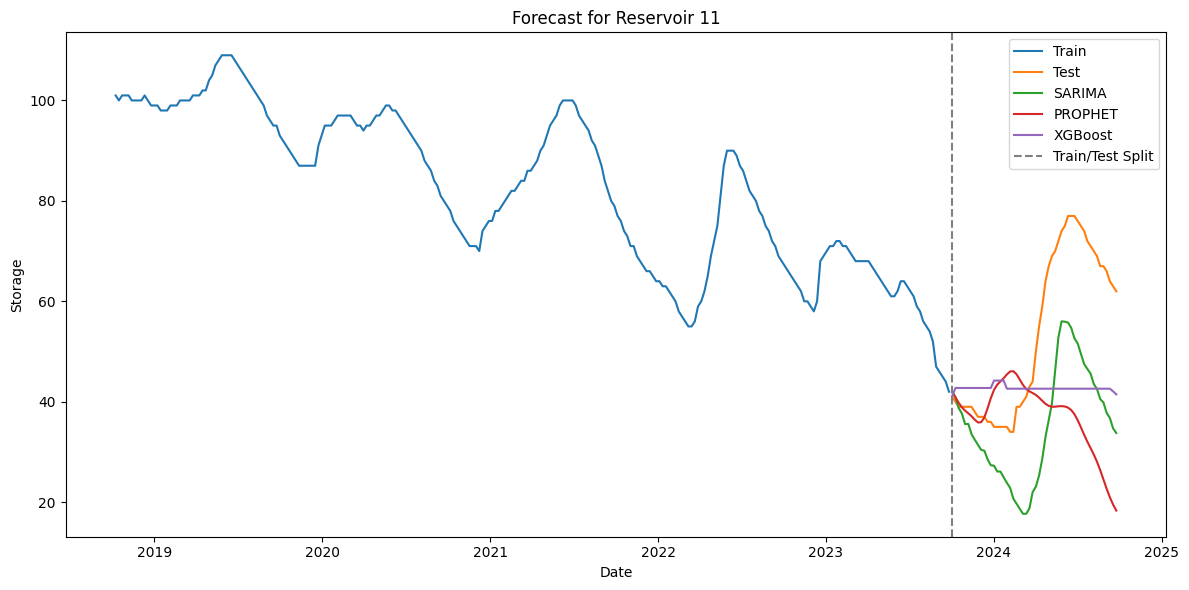

In [9]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[-(52*6):-52]
test = series.iloc[-52:]


# Instantiate and fit SARIMAModel
model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
model.fit(train)

forecast_SARIMA = model.predict(steps=52)

results = model.evaluate(test, forecast_SARIMA)


model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0000.5)
model.fit(train)

# Make predictions
forecast_PROPHET = model.predict(52)


# Set date as index
df_res.set_index('date', inplace=True)

df_res = df_res.iloc[-(52*8):]

# Keep only storage for lag feature creation
storage_series = df_res['storage'] # / capacity  # Convert to percentage

df_res['seasonality'] = 52

# Create lag features for the last 3 years
YEARS_BACK = 2
weeks_back = 52 * YEARS_BACK  # 156 weeks

# Create all lag features efficiently using pd.concat
lag_features = {}
'''
for lag in range(1, weeks_back + 1):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)
'''

for lag in range(1,9):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

for lag in range(46, 59):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

for lag in range(98, 111):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

for lag in range(150, 163):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

# Create DataFrame with all features at once
lag_data = pd.DataFrame({
    'year': df_res['year'].astype(float),
    'month': df_res['month'] / 12,
    'week_idx': df_res['week_idx'] / 52,
    "seasonality" : df_res['seasonality'],
    'next_storage_value': storage_series.shift(-1),
    **lag_features  # Unpack all lag features

}, index=storage_series.index)

# Remove rows with NaN values (first 3 years and last row)
# lag_data = lag_data.dropna()
lag_data = lag_data[52*3:]

print(f"Original data shape: {df_res.shape}")
print(f"Prepared data shape: {lag_data.shape}")
print(f"Features created: {lag_data.shape[1] - 1} (excluding target)")
print(f"Lag features: {weeks_back}")

# Split into train/test: last 52 weeks as test
train = lag_data.iloc[:-52]
test_features = lag_data.iloc[-52:].drop('next_storage_value', axis=1)
test_target = lag_data.iloc[-52:]['next_storage_value']


# Scale year feature
year_scaler = MinMaxScaler()
train.loc[:, 'year'] = year_scaler.fit_transform(train['year'].values.reshape(-1, 1)).flatten()
test_features.loc[:, 'year'] = year_scaler.transform(test_features['year'].values.reshape(-1, 1)).flatten()


print(f"Training data shape: {train.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"Test target shape: {test_target.shape}")

# Create and train XGBoost model
model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
model.fit(train)

# Generate forecasts for 52 steps
forecast_values = model.predict(steps=52)

# Create forecast series with same index as test_target
forecast = pd.Series(forecast_values, index=test_target.index)

# Scale both test and forecast back to original capacity for evaluation
test_target_scaled = test_target # * capacity
forecast_scaled = forecast # * capacity

# Adjust negative predictions
def adjust_negatives(predictions):
    predictions = np.array(predictions)
    for i in range(len(predictions)):
        if predictions[i] < 0:
            correction = -predictions[i]
            predictions[i:] += correction
    return predictions

forecast_scaled = pd.Series(adjust_negatives(forecast_scaled), index=forecast_scaled.index)

plt.figure(figsize=(12, 6))

# Plot training and test data using original series
train_series = series.iloc[-(52*6):-52]  # Use original series for plotting
test_series = series.iloc[-52:]  # Use original series for plotting

plt.plot(train_series.index, train_series, label='Train')
plt.plot(test_series.index, test_series, label='Test')
plt.plot(test_series.index, forecast_SARIMA, label='SARIMA')
plt.plot(test_series.index, forecast_PROPHET, label='PROPHET')
plt.plot(test_series.index, forecast_scaled, label='XGBoost')

# Add train/test split line
plt.axvline(test_series.index[0], color='gray', linestyle='--', label='Train/Test Split')

# Formatting
plt.legend()
title = f'Forecast for Reservoir {reservoir_id}'
plt.title(title)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

In [ ]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[-(52*6):-52]
test = series.iloc[-52:]


# Instantiate and fit SARIMAModel
model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
model.fit(train)

forecast_SARIMA = model.predict(steps=52)

results = model.evaluate(test, forecast_SARIMA)


model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0000.5)
model.fit(train)

# Make predictions
forecast_PROPHET = model.predict(52)


# Set date as index
df_res.set_index('date', inplace=True)

df_res = df_res.iloc[-(52*8):]

# Keep only storage for lag feature creation
storage_series = df_res['storage'] # / capacity  # Convert to percentage

df_res['seasonality'] = 52

# Create lag features for the last 3 years
YEARS_BACK = 2
weeks_back = 52 * YEARS_BACK  # 156 weeks

# Create all lag features efficiently using pd.concat
lag_features = {}
'''
for lag in range(1, weeks_back + 1):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)
'''

for lag in range(1,9):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

for lag in range(46, 59):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

for lag in range(98, 111):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

for lag in range(150, 163):
    lag_features[f'storage_lag_{lag}'] = storage_series.shift(lag)

# Create DataFrame with all features at once
lag_data = pd.DataFrame({
    'year': df_res['year'].astype(float),
    'month': df_res['month'] / 12,
    'week_idx': df_res['week_idx'] / 52,
    "seasonality" : df_res['seasonality'],
    'next_storage_value': storage_series.shift(-1),
    **lag_features  # Unpack all lag features

}, index=storage_series.index)

# Remove rows with NaN values (first 3 years and last row)
# lag_data = lag_data.dropna()
lag_data = lag_data[52*3:]

print(f"Original data shape: {df_res.shape}")
print(f"Prepared data shape: {lag_data.shape}")
print(f"Features created: {lag_data.shape[1] - 1} (excluding target)")
print(f"Lag features: {weeks_back}")

# Split into train/test: last 52 weeks as test
train = lag_data.iloc[:-52]
test_features = lag_data.iloc[-52:].drop('next_storage_value', axis=1)
test_target = lag_data.iloc[-52:]['next_storage_value']


# Scale year feature
year_scaler = MinMaxScaler()
train.loc[:, 'year'] = year_scaler.fit_transform(train['year'].values.reshape(-1, 1)).flatten()
test_features.loc[:, 'year'] = year_scaler.transform(test_features['year'].values.reshape(-1, 1)).flatten()


print(f"Training data shape: {train.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"Test target shape: {test_target.shape}")

# Create and train XGBoost model
model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
model.fit(train)

# Generate forecasts for 52 steps
forecast_values = model.predict(steps=52)

# Create forecast series with same index as test_target
forecast = pd.Series(forecast_values, index=test_target.index)

# Scale both test and forecast back to original capacity for evaluation
test_target_scaled = test_target # * capacity
forecast_scaled = forecast # * capacity

# Adjust negative predictions
def adjust_negatives(predictions):
    predictions = np.array(predictions)
    for i in range(len(predictions)):
        if predictions[i] < 0:
            correction = -predictions[i]
            predictions[i:] += correction
    return predictions

forecast_scaled = pd.Series(adjust_negatives(forecast_scaled), index=forecast_scaled.index)

plt.figure(figsize=(12, 6))

# Plot training and test data using original series
train_series = series.iloc[-(52*6):-52]  # Use original series for plotting
test_series = series.iloc[-52:]  # Use original series for plotting

plt.plot(train_series.index, train_series, label='Train')
plt.plot(test_series.index, test_series, label='Test')
plt.plot(test_series.index, forecast_SARIMA, label='SARIMA')
plt.plot(test_series.index, forecast_PROPHET, label='PROPHET')
plt.plot(test_series.index, forecast_scaled, label='XGBoost')

# Add train/test split line
plt.axvline(test_series.index[0], color='gray', linestyle='--', label='Train/Test Split')

# Formatting
plt.legend()
title = f'Forecast for Reservoir {reservoir_id}'
plt.title(title)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

# We start with the simplest stacking model

In [12]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

In [ ]:
# Train/test split: last 52 weeks as test
train_series = series.iloc[-(52*8):-52] # 7 years
test_series = series.iloc[-52:] # 1 year

train_stacking_index = train_series[-(52*3):].index  # Last 3 years for training the stacking one
# Create a dataframe with train_index as index
train_stacking = pd.DataFrame(index=train_stacking_index)
train_stacking['storage'] = train_series[-(52*3):]  # Last 3 years from train_series of storage
train_stacking['sarima_prediction'] = np.nan
train_stacking['prophet_prediction'] = np.nan

test_stacking_index = test_series.index  # Last year for testing the stacking one
test_stacking = pd.DataFrame(index=test_stacking_index)
test_stacking['storage'] = test_series
test_stacking['sarima_prediction'] = np.nan
test_stacking['prophet_prediction'] = np.nan

for i in range(3):
    # print(f"Starting SARIMA model training for iteration {i}")
    sarima_model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
    sarima_model.fit(train_series.iloc[-(52*(i+1)):-52*(i+4)])
    # print(f"\n Selecting from {train_series.index[-(52*(i+1)):-52*(i+4)]}")
    # print(f"\n train_series size: {train_series.shape}")
    sarima_test_pred = sarima_model.predict(steps=52)
    train_stacking.iloc[(52*(8-i)):(52*(8-i+1)), train_stacking.columns.get_loc('sarima_prediction')] = sarima_test_pred

'''
for i in range(8, 5, -1):
    sarima_model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
    sarima_model.fit(train_series.iloc[-(52*i):-(52*(i-4))])
    sarima_test_pred = sarima_model.predict(steps=52)
    train_stacking.iloc[(52*(8-i)):(52*(8-i+1)), train_stacking.columns.get_loc('sarima_prediction')] = sarima_test_pred
'''

for i in range(3):
    # print(f"Starting Prophet model training for iteration {i}")
    prophet_model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
    prophet_model.fit(train_series.iloc[(52*i):(52*(i+4))])
    # print(f"\n Selecting from {train_series.index[(52*i):(52*(i+4))]}")
    # print(f"\n train_series size: {train_series.shape}")
    prophet_test_pred = prophet_model.predict(steps=52)
    # print(f"\n Shape of Prophet predictions for iteration {i}: {prophet_test_pred.shape}")
    train_stacking.iloc[(52*i):(52*(i+1)), train_stacking.columns.get_loc('prophet_prediction')] = prophet_test_pred

# Predicting prophet for test data
prophet_model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
prophet_model.fit(train_series[-(52*4):])
# print(f"\n Selecting from {train_series.index[-(52*4):]}")
prophet_test_pred = prophet_model.predict(steps=52)
prophet_test_pred.index = test_stacking.index
prophet_test_pred.head()

test_stacking['prophet_prediction'] = prophet_test_pred
# print(f"\nFinal train stacking DataFrame shape: {train_stacking.shape}")
# test_stacking.info()

00:45:54 - cmdstanpy - INFO - Chain [1] start processing
00:45:54 - cmdstanpy - INFO - Chain [1] done processing
00:45:54 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
00:45:54 - cmdstanpy - INFO - Chain [1] start processing
00:45:54 - cmdstanpy - INFO - Chain [1] done processing
00:45:54 - cmdstanpy - INFO - Chain [1] start processing
00:45:54 - cmdstanpy - INFO - Chain [1] done processing
00:45:54 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
00:45:54 - cmdstanpy - INFO - Chain [1] start processing
00:45:55 - cmdstanpy - INFO - Chain [1] done processing
00:45:55 - cmdstanpy - INFO - Chain [1] start processing
00:45:55 - cmdstanpy - INFO - Chain [1] done processing
00:45:55 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abn

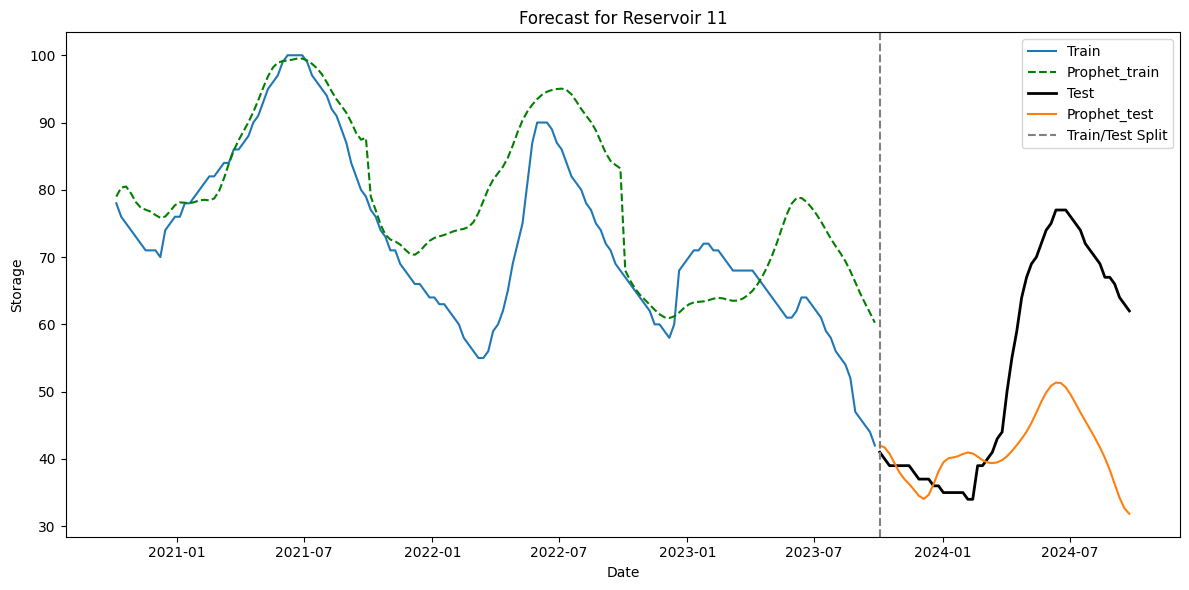

            storage  sarima_prediction  prophet_prediction
date                                                      
2023-08-29     47.0                NaN           66.257569
2023-09-05     46.0                NaN           64.616388
2023-09-12     45.0                NaN           63.121604
2023-09-19     44.0                NaN           61.714171
2023-09-26     42.0                NaN           60.245280


In [6]:
plt.figure(figsize=(12, 6))

# Plot training and test data
plt.plot(train_stacking.index, train_stacking['storage'], label='Train')
# plt.plot(train_stacking.index, train_stacking['sarima_prediction'], label='SARIMA_train', color='red', linestyle='--')
plt.plot(train_stacking.index, train_stacking['prophet_prediction'], label='Prophet_train', color='green', linestyle='--')
plt.plot(test_stacking.index, test_stacking['storage'], label='Test', color='black', linewidth=2)
plt.plot(test_stacking.index, test_stacking['prophet_prediction'], label='Prophet_test')

# Add train/test split line
plt.axvline(test_stacking.index[0], color='gray', linestyle='--', label='Train/Test Split')

# Formatting
plt.legend()
title = f'Forecast for Reservoir {reservoir_id}'
plt.title(title)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

print(train_stacking.tail())

In [ ]:
train_stacking.drop(columns=['sarima_prediction'], inplace=True)
train_stacking['next_storage_value'] = train_stacking['storage'].shift(-1)
train_stacking.dropna(inplace=True)
train_stacking.head()

In [ ]:
test_stacking.drop(columns=['sarima_prediction'], inplace=True)
test_stacking['next_storage_value'] = test_stacking['storage'].shift(-1)
test_stacking.dropna(inplace=True)
test_stacking.head()

In [ ]:
test_stacking.info()

In [ ]:
y = test_stacking['next_storage_value']
test_stacking.drop(columns=['next_storage_value'], inplace=True)

In [ ]:
train_stacking.tail()

# Good predict, but with storages from next year

In [ ]:
model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
predictions = []

for step in range(51):
    # Fit the model on the training data
    model.fit(train_stacking)
    
    # Predict the next value
    forecast_values = model.predict(steps=1)

    prediction = forecast_values[0]
    predictions.append(prediction)

    # Update the training data with the new prediction
    '''
    next_row = {
        'year': train_stacking['year'].iloc[-1],
        'month': train_stacking['month'].iloc[-1],
        'week_idx': train_stacking['week_idx'].iloc[-1],
        'next_storage_value': forecast_values[0],
        **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(1, 9)},
        **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(46, 59)},
        **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(98, 111)},
        **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(150, 163)}
    }
    '''

    next_row = test_stacking.iloc[step].to_dict()
    
    # Append the new row to the training data
    new_df = pd.DataFrame([next_row], index=[train_stacking.index[-1] + pd.Timedelta(weeks=1)])
    new_df['next_storage_value'] = predictions[-1]
    new_df['storage'] = train_stacking['next_storage_value'].iloc[-1]  # Use the last known storage value
    train_stacking = pd.concat([train_stacking, new_df], axis=0)

# Create forecast series with same index as test_target
forecast = pd.Series(predictions, index=test_stacking.index)

In [ ]:
plt.figure(figsize=(12, 6))

# Plot training and test data
plt.plot(train_stacking.index, train_stacking['storage'], label='Train')
# plt.plot(train_stacking.index, train_stacking['sarima_prediction'], label='SARIMA_train', color='red', linestyle='--')
plt.plot(train_stacking.index, train_stacking['prophet_prediction'], label='Prophet_train', color='green', linestyle='--')
plt.plot(test_stacking.index, test_stacking['storage'], label='Test', color='black', linewidth=2)
plt.plot(test_stacking.index, test_stacking['prophet_prediction'], label='Prophet_test')
plt.plot(test_stacking.index, forecast, label='XGBoost Stacking', color='purple')

# Add train/test split line
plt.axvline(test_stacking.index[0], color='gray', linestyle='--', label='Train/Test Split')

# Formatting
plt.legend()
title = f'Forecast for Reservoir {reservoir_id}'
plt.title(title)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

# Predict with storages previously predicted

In [ ]:
model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
model.fit(train_stacking)
predictions = []
test_modified = test_stacking.copy()


for step in range(len(test_stacking)):
    if step == 0:
        prediction = model.predict(test_modified.iloc[[step]])
    else:
        # Update the test_modified with the previous prediction
        test_modified.iloc[step, test_modified.columns.get_loc('storage')] = predictions[-1]
        prediction = model.predict(test_modified.iloc[[step]])

    predictions.append(prediction)

# Update the training data with the new prediction
'''
next_row = {
    'year': train_stacking['year'].iloc[-1],
    'month': train_stacking['month'].iloc[-1],
    'week_idx': train_stacking['week_idx'].iloc[-1],
    'next_storage_value': forecast_values[0],
    **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(1, 9)},
    **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(46, 59)},
    **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(98, 111)},
    **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(150, 163)}
}
'''

'''
next_row = test_stacking.iloc[step].to_dict()

# Append the new row to the training data
new_df = pd.DataFrame([next_row], index=[train_stacking.index[-1] + pd.Timedelta(weeks=1)])
new_df['next_storage_value'] = y.iloc[step]
new_df['storage'] = predictions[-1]
train_stacking = pd.concat([train_stacking, new_df], axis=0)
'''

'''
# Append the new row to the training data
new_df = pd.DataFrame([next_row], index=[train_stacking.index[-1] + pd.Timedelta(weeks=1)])
new_df['next_storage_value'] = predictions[-1]
new_df['storage'] = train_stacking['next_storage_value'].iloc[-1]  # Use the last known storage value
train_stacking = pd.concat([train_stacking, new_df], axis=0)
'''

# Create forecast series with same index as test_target
forecast = pd.Series(predictions, index=test_stacking.index)

In [ ]:
plt.figure(figsize=(12, 6))

# Plot training and test data
plt.plot(train_stacking.index, train_stacking['storage'], label='Train')
# plt.plot(train_stacking.index, train_stacking['sarima_prediction'], label='SARIMA_train', color='red', linestyle='--')
plt.plot(train_stacking.index, train_stacking['prophet_prediction'], label='Prophet_train', color='green', linestyle='--')
plt.plot(test_stacking.index, test_stacking['storage'], label='Test', color='black', linewidth=2)
plt.plot(test_stacking.index, test_stacking['prophet_prediction'], label='Prophet_test')
plt.plot(test_stacking.index, forecast, label='XGBoost Stacking', color='purple')

# Add train/test split line
plt.axvline(test_stacking.index[0], color='gray', linestyle='--', label='Train/Test Split')

# Formatting
plt.legend()
title = f'Forecast for Reservoir {reservoir_id}'
plt.title(title)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

print(train_stacking.tail())

# All together

In [ ]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train_series = series.iloc[-(52*8):-52] # 7 years
test_series = series.iloc[-52:] # 1 year

train_stacking_index = train_series[-(52*3):].index  # Last 3 years for training the stacking one
# Create a dataframe with train_index as index
train_stacking = pd.DataFrame(index=train_stacking_index)
train_stacking['storage'] = train_series[-(52*3):]  # Last 3 years from train_series of storage
train_stacking['sarima_prediction'] = np.nan
train_stacking['prophet_prediction'] = np.nan

test_stacking_index = test_series.index  # Last year for testing the stacking one
test_stacking = pd.DataFrame(index=test_stacking_index)
test_stacking['storage'] = test_series
test_stacking['sarima_prediction'] = np.nan
test_stacking['prophet_prediction'] = np.nan

'''
for i in range(8, 5, -1):
    sarima_model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
    sarima_model.fit(train_series.iloc[-(52*i):-(52*(i-4))])
    sarima_test_pred = sarima_model.predict(steps=52)
    train_stacking.iloc[(52*(8-i)):(52*(8-i+1)), train_stacking.columns.get_loc('sarima_prediction')] = sarima_test_pred
'''

for i in range(3):
    # print(f"Starting Prophet model training for iteration {i}")
    prophet_model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
    prophet_model.fit(train_series.iloc[(52*i):(52*(i+4))])
    # print(f"\n Selecting from {train_series.index[(52*i):(52*(i+4))]}")
    # print(f"\n train_series size: {train_series.shape}")
    prophet_test_pred = prophet_model.predict(steps=52)
    # print(f"\n Shape of Prophet predictions for iteration {i}: {prophet_test_pred.shape}")
    train_stacking.iloc[(52*i):(52*(i+1)), train_stacking.columns.get_loc('prophet_prediction')] = prophet_test_pred

# Predicting prophet for test data
prophet_model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.0005)
prophet_model.fit(train_series[-(52*4):])
# print(f"\n Selecting from {train_series.index[-(52*4):]}")
prophet_test_pred = prophet_model.predict(steps=52)
prophet_test_pred.index = test_stacking.index
prophet_test_pred.head()

test_stacking['prophet_prediction'] = prophet_test_pred
# print(f"\nFinal train stacking DataFrame shape: {train_stacking.shape}")
# test_stacking.info()

plt.figure(figsize=(12, 6))

# Plot training and test data
plt.plot(train_stacking.index, train_stacking['storage'], label='Train')
# plt.plot(train_stacking.index, train_stacking['sarima_prediction'], label='SARIMA_train', color='red', linestyle='--')
plt.plot(train_stacking.index, train_stacking['prophet_prediction'], label='Prophet_train', color='green', linestyle='--')
plt.plot(test_stacking.index, test_stacking['storage'], label='Test', color='black', linewidth=2)
plt.plot(test_stacking.index, test_stacking['prophet_prediction'], label='Prophet_test')

# Add train/test split line
plt.axvline(test_stacking.index[0], color='gray', linestyle='--', label='Train/Test Split')

# Formatting
plt.legend()
title = f'Forecast for Reservoir {reservoir_id}'
plt.title(title)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

train_stacking.drop(columns=['sarima_prediction'], inplace=True)
train_stacking['next_storage_value'] = train_stacking['storage'].shift(-1)
train_stacking.dropna(inplace=True)
train_stacking.head()

test_stacking.drop(columns=['sarima_prediction'], inplace=True)
test_stacking['next_storage_value'] = test_stacking['storage'].shift(-1)
test_stacking.dropna(inplace=True)
test_stacking.head()

y = test_stacking['next_storage_value']
test_stacking.drop(columns=['next_storage_value'], inplace=True)

model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
predictions = []

for step in range(51):
    # Fit the model on the training data
    model.fit(train_stacking)
    
    # Predict the next value
    forecast_values = model.predict(steps=1)

    prediction = forecast_values[0]
    predictions.append(prediction)

    # Update the training data with the new prediction
    '''
    next_row = {
        'year': train_stacking['year'].iloc[-1],
        'month': train_stacking['month'].iloc[-1],
        'week_idx': train_stacking['week_idx'].iloc[-1],
        'next_storage_value': forecast_values[0],
        **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(1, 9)},
        **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(46, 59)},
        **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(98, 111)},
        **{f'storage_lag_{lag}': train_stacking[f'storage_lag_{lag}'].iloc[-1] for lag in range(150, 163)}
    }
    '''

    next_row = test_stacking.iloc[step].to_dict()
    
    # Append the new row to the training data
    new_df = pd.DataFrame([next_row], index=[train_stacking.index[-1] + pd.Timedelta(weeks=1)])
    new_df['next_storage_value'] = y.iloc[step]
    new_df['storage'] = predictions[-1]
    train_stacking = pd.concat([train_stacking, new_df], axis=0)

    '''
    # Append the new row to the training data
    new_df = pd.DataFrame([next_row], index=[train_stacking.index[-1] + pd.Timedelta(weeks=1)])
    new_df['next_storage_value'] = predictions[-1]
    new_df['storage'] = train_stacking['next_storage_value'].iloc[-1]  # Use the last known storage value
    train_stacking = pd.concat([train_stacking, new_df], axis=0)
    '''

# Create forecast series with same index as test_target
forecast = pd.Series(predictions, index=test_stacking.index)

In [ ]:
plt.figure(figsize=(12, 6))

# Plot training and test data
plt.plot(train_stacking.index, train_stacking['storage'], label='Train')
# plt.plot(train_stacking.index, train_stacking['sarima_prediction'], label='SARIMA_train', color='red', linestyle='--')
plt.plot(train_stacking.index, train_stacking['prophet_prediction'], label='Prophet_train', color='green', linestyle='--')
plt.plot(test_stacking.index, test_stacking['storage'], label='Test', color='black', linewidth=2)
plt.plot(test_stacking.index, test_stacking['prophet_prediction'], label='Prophet_test')
plt.plot(test_stacking.index, forecast, label='XGBoost Stacking', color='purple')

# Add train/test split line
plt.axvline(test_stacking.index[0], color='gray', linestyle='--', label='Train/Test Split')

# Formatting
plt.legend()
title = f'Forecast for Reservoir {reservoir_id}'
plt.title(title)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

In [ ]:
train_stacking.tail()

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
show = test_stacking.copy()
show['predictions'] = forecast
show

In [ ]:
train_stacking.drop(columns=['sarima_prediction'], inplace=True)
train_stacking['next_storage_value'] = train_stacking['storage'].shift(-1)
train_stacking.dropna(inplace=True)
train_stacking.head()

In [14]:
# Create and train XGBoost model
model = XGBoostModel(n_estimators=100, max_depth=6, learning_rate=0.1)
predictions = []

def predict_next_year(X):
    for week in range(1, 53):
        X_step = X.copy()
        X_step.drop(columns=['sarima_prediction'], inplace=True)
        last_row = X_step.iloc[-1]
        X_step['next_storage_value'] = X_step['storage'].shift(-week)
        X_step = X_step.iloc[:-52]
        
        print(f"\n X_step from step {week}: \n {X_step}")
        model.fit(X_step)
        
        
        # Generate forecasts for 52 steps
        prediction = model.predict(last_row.to_frame().T)
        predictions.append(prediction)

    # Create forecast series with same index as test_stacking
    forecast = pd.Series(predictions, index=test_stacking.index)
    return forecast

forecast = predict_next_year(train_stacking)
print(forecast)


 X_step from step 1: 
             storage  prophet_prediction  next_storage_value
date                                                       
2020-10-06     78.0           79.000000                76.0
2020-10-13     76.0           80.327543                75.0
2020-10-20     75.0           80.487345                74.0
2020-10-27     74.0           79.480689                73.0
2020-11-03     73.0           78.167610                72.0
...             ...                 ...                 ...
2022-08-30     74.0           87.170471                72.0
2022-09-06     72.0           85.485288                71.0
2022-09-13     71.0           84.287416                69.0
2022-09-20     69.0           83.690740                68.0
2022-09-27     68.0           83.183316                67.0

[104 rows x 3 columns]

 X_step from step 2: 
             storage  prophet_prediction  next_storage_value
date                                                       
2020-10-06     78.0         

In [16]:
train_stacking

,storage,sarima_prediction,prophet_prediction
date,,,
2020-10-06,78.0,NaN,79.000000
2020-10-13,76.0,NaN,80.327543
2020-10-20,75.0,NaN,80.487345
2020-10-27,74.0,NaN,79.480689
2020-11-03,73.0,NaN,78.167610
...,...,...,...
2023-08-29,47.0,NaN,66.257569
2023-09-05,46.0,NaN,64.616388
2023-09-12,45.0,NaN,63.121604


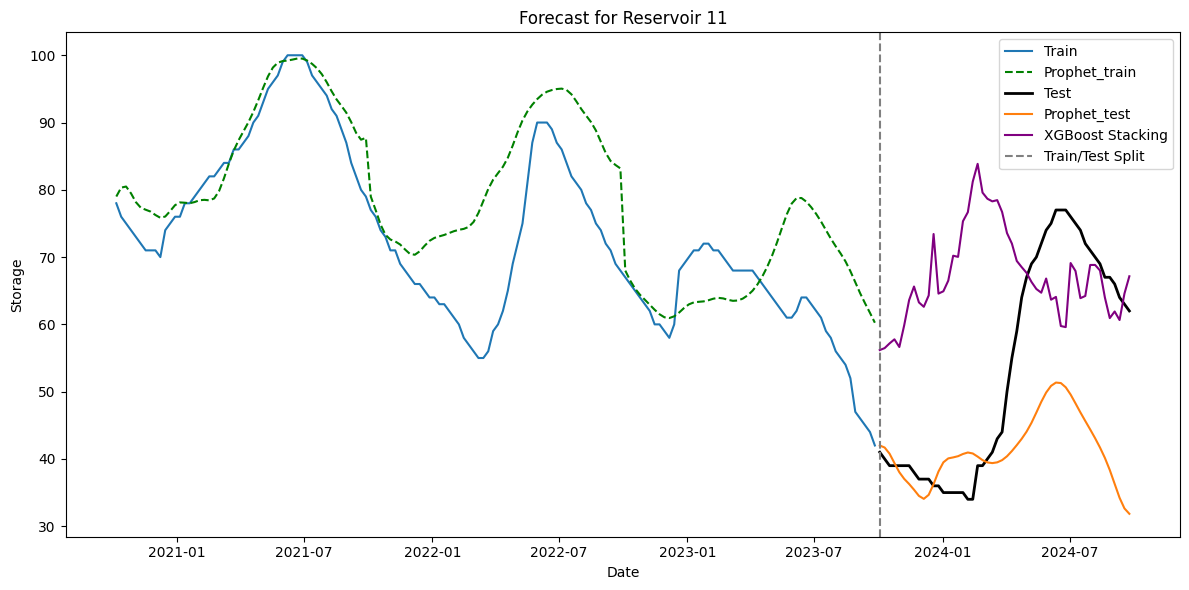

In [15]:
plt.figure(figsize=(12, 6))

# Plot training and test data
plt.plot(train_stacking.index, train_stacking['storage'], label='Train')
# plt.plot(train_stacking.index, train_stacking['sarima_prediction'], label='SARIMA_train', color='red', linestyle='--')
plt.plot(train_stacking.index, train_stacking['prophet_prediction'], label='Prophet_train', color='green', linestyle='--')
plt.plot(test_stacking.index, test_stacking['storage'], label='Test', color='black', linewidth=2)
plt.plot(test_stacking.index, test_stacking['prophet_prediction'], label='Prophet_test')
plt.plot(test_stacking.index, forecast, label='XGBoost Stacking', color='purple')

# Add train/test split line
plt.axvline(test_stacking.index[0], color='gray', linestyle='--', label='Train/Test Split')

# Formatting
plt.legend()
title = f'Forecast for Reservoir {reservoir_id}'
plt.title(title)
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

In [ ]:
train_stacking